# Three-Dimensional Plotting in Matplotlib

Three-dimensional plots are enabled by importing the mplot3d toolkit, included with the main Matplotlib installation

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

Once this submodule is imported, a three-dimensional axes can be created by passing the keyword **projection='3d'** to any of the normal axes creation routines:

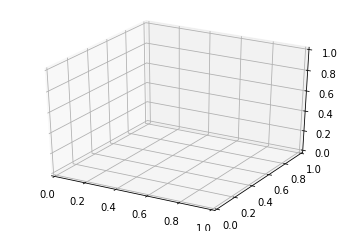

In [ ]:
ax = plt.axes(projection='3d')

With this three-dimensional axes enabled, we can now plot a variety of three-dimensional plot types.

## Three-dimensional Points and Lines
The most basic three-dimensional plot is a line or collection of scatter plot created from sets of (x, y, z) triples. In analogy with the more common two-dimensional plots discussed earlier, these can be created using the **ax.plot3D** and **ax.scatter3D** functions.

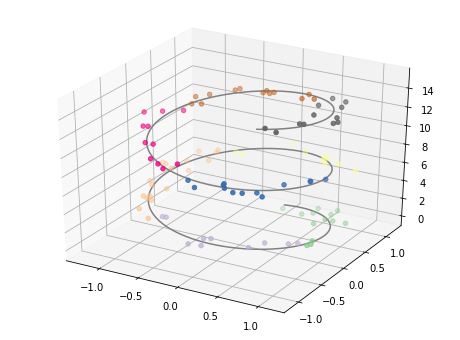

In [ ]:
plt.rcParams['figure.figsize'] = 8, 6

ax = plt.axes(projection='3d')
zline = np.linspace(0, 15, 1000)
xline = np.sin(zline)
yline = np.cos(zline)
ax.plot3D(xline, yline, zline, 'gray')

# Data for three-dimensional scattered points
zdata = 15 * np.random.random(100)
xdata = np.sin(zdata) + 0.1 * np.random.randn(100)
ydata = np.cos(zdata) + 0.1 * np.random.randn(100)
ax.scatter3D(xdata, ydata, zdata, c=zdata, cmap='Accent');

## Three-dimensional Contour Plots
Like two-dimensional **ax.contour** plots, **ax.contour3D** requires all the input data to be in the form of two-dimensional regular grids, with the Z data evaluated at each point. Here we'll show a three-dimensional contour diagram of a three-dimensional sinusoidal function:

In [ ]:
def f(x, y):
    return np.sin(np.sqrt(x ** 2 + y ** 2))

x = np.linspace(-6, 6, 30)
y = np.linspace(-6, 6, 30)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

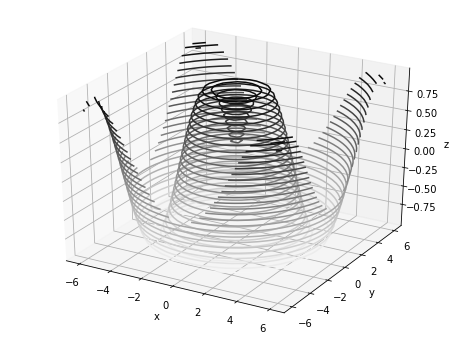

In [ ]:
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.contour3D(X, Y, Z, 30, cmap='binary')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z');

Sometimes the default viewing angle is not optimal, in which case we can use the **view_init** method to set the elevation and azimuthal angles. In the following example, we'll use an elevation of 60 degrees (that is, 60 degrees above the x-y plane) and an azimuth of 70 degrees (that is, rotated 70 degrees counter-clockwise about the z-axis):

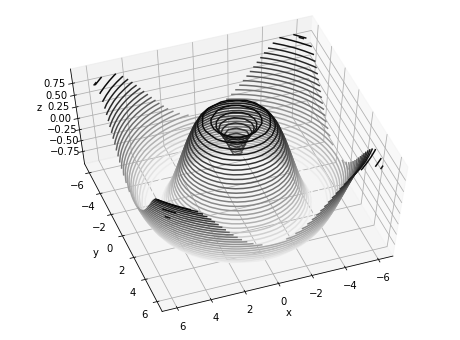

In [ ]:
# %matplotlib inline
ax.view_init(60, 70)
fig

## Surface Triangulation

Triangulation of a surface is the procedure of generating a net of triangles, which covers a given surface partly or totally. 

Suppose we have a set of random points in Polar coordinates $(r, \phi)$ and we want to see the surface of a function $f(x, y)$ obtained from the corresponding Cartesian points $(x,y)$.

![](https://upload.wikimedia.org/wikipedia/commons/thumb/7/78/Polar_to_cartesian.svg/375px-Polar_to_cartesian.svg.png)

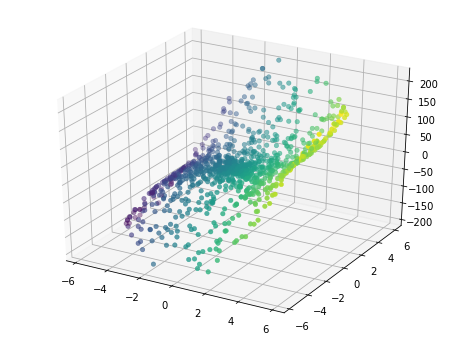

In [ ]:
plt.rcParams['figure.figsize'] = 8, 6

f = lambda x, y: x ** 3 + y ** 3
phi = 2 * np.pi * np.random.random(1000)
r = 6 * np.random.random(1000)
x = r * np.sin(phi)
y = r * np.cos(phi)
z = f(x, y)
ax = plt.axes(projection='3d')
ax.scatter(x, y, z, c=x, cmap='viridis', linewidth=0.5);

We can use the `plot_triusurf()` function to plut the triangular surface.

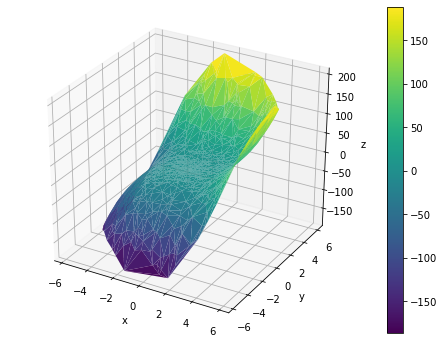

In [ ]:
fig = plt.figure()
ax = plt.axes(projection='3d')
p = ax.plot_trisurf(x, y, z, 
                cmap='viridis', edgecolor='none');

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

fig.colorbar(p);

# if we want to visualize from another angle
# ax.view_init(30, 120);

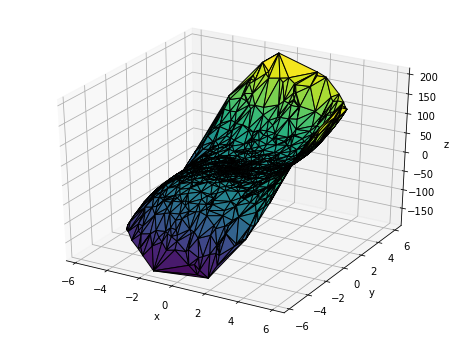

In [ ]:
ax = plt.axes(projection='3d')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

ax.plot_trisurf(x, y, z, 
                cmap='viridis', edgecolor='k');


## Wireframes and Surface Plots
Two other types of three-dimensional plots that work on gridded data are wireframes and surface plots. These take a grid of values and project it onto the specified three-dimensional surface, and can make the resulting three-dimensional forms quite easy to visualize. Here's an example of using a wireframe:

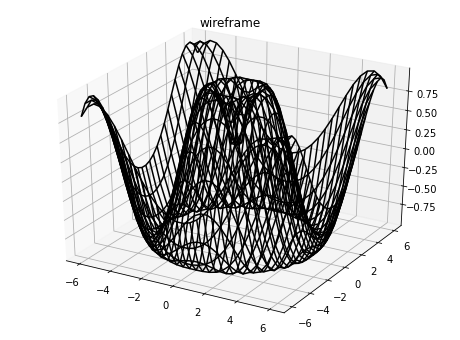

In [ ]:
ax = plt.axes(projection='3d')
ax.plot_wireframe(X, Y, Z, color='black')
ax.set_title('wireframe');

A surface plot is like a wireframe plot, but each face of the wireframe is a filled polygon. Adding a colormap to the filled polygons can aid perception of the topology of the surface being visualized:

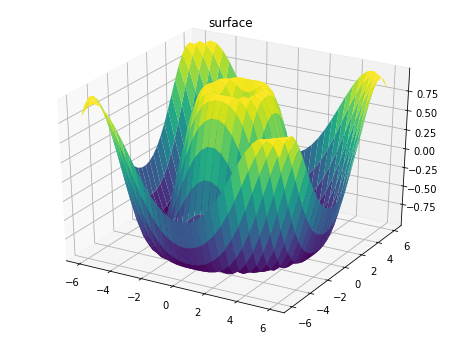

In [ ]:
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, rstride=1, cstride=1,
                cmap='viridis', edgecolor='none')
ax.set_title('surface');

## 3D Bar Plots

Each bar in a bar plot always needs 2 things: a position and a size. With 3D bar plots, we're going to supply that information for all three variables $x, y, z$.
We will select the z axis to encode the height of each bar; therefore, each bar will start at $z = 0$ and have a size that is proportional to the value we are trying to visualise. The $x$ and $y$ positions will represent the coordinates of the bar across the 2D plane of $z = 0$. We'll set the $x$ and $y$ size of each bar to a value of $1$ so that all the bars have the same shape.

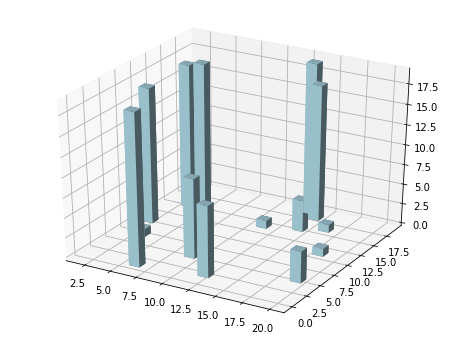

In [ ]:
fig = plt.figure()
ax = plt.axes(projection="3d")

num_bars = 15
x_pos = np.random.choice(range(20), num_bars)
y_pos = np.random.choice(range(20), num_bars)
z_pos = np.zeros(num_bars)

x_size = np.ones(num_bars)
y_size = np.ones(num_bars)
z_size = np.random.choice(range(20), num_bars)

ax.bar3d(x_pos, y_pos, z_pos, x_size, y_size, z_size, color='lightblue')
plt.show()

# Visualize Geographic Data

## Basemap
One common type of visualization in data science is that of geographic data. Matplotlib's main tool for this type of visualization is the **Basemap** toolkit, which is one of several Matplotlib toolkits which lives under the **mpl_toolkits** namespace.

Installation of Basemap is straightforward; if you're using conda you can type this and the package will be downloaded:

`conda install basemap`

Before importing the toolkit, let's import a dataset that contains coordinates of interest that we want to plot on a map. The dataset that we will work with is *UCDP Georeferenced Event Dataset (GED) Global version 19.1* ([link](https://ucdp.uu.se/downloads/index.html#ged_global)). The dataset covers individual events of organized violence. 
These events are sufficiently fine-grained to be geo-coded down to the level of individual villages, with temporal durations disaggregated to single, individual days.
More info about the features of this dataset can be found [here](https://ucdp.uu.se/downloads/ged/ged191.pdf) (6-11 pages).

In [ ]:
!curl -O https://ucdp.uu.se/downloads/ged/ged201-csv.zip
!unzip ged201-csv.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 16.8M  100 16.8M    0     0   222k      0  0:01:17  0:01:17 --:--:--  660k
Archive:  ged201-csv.zip
  inflating: ged201.csv              


In [ ]:
df = pd.read_csv('ged201.csv')
df.shape

/usr/local/lib/python3.6/dist-packages/IPython/core/interactiveshell.py:2718: DtypeWarning: Columns (47) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


(225385, 49)

In [ ]:
# print(df.columns)
df.head()

,id,relid,year,active_year,code_status,type_of_violence,conflict_dset_id,conflict_new_id,conflict_name,dyad_dset_id,dyad_new_id,dyad_name,side_a_dset_id,side_a_new_id,side_a,side_b_dset_id,side_b_new_id,side_b,number_of_sources,source_article,source_office,source_date,source_headline,source_original,where_prec,where_coordinates,where_description,adm_1,adm_2,latitude,longitude,geom_wkt,priogrid_gid,country,country_id,region,event_clarity,date_prec,date_start,date_end,deaths_a,deaths_b,deaths_civilians,deaths_unknown,best,high,low,gwnoa,gwnob
0,244657,IRQ-2017-1-524-322,2017,1,Clear,1,259,259,Iraq: Government,524,524,Government of Iraq - IS,116,116,Government of Iraq,234,234,IS,3,"""Agence France Presse,2017-08-01,Attackers tar...",Agence France Presse;Agence France Presse;Pajh...,2017-08-01;2017-08-01;2017-07-31,Attackers target Shiite mosque in Afghanistan'...,"IS, interior ministry, security source",1,Kabul city,Iraqi embassy in Kabul,Kabul province,Kabul district,34.531094,69.162796,POINT (69.162796 34.531094),179779,Afghanistan,700,Asia,1,1,2017-07-31 00:00:00.000,2017-07-31 00:00:00.000,0,4,0,2,6,6,6,645,NaN
1,132140,AFG-1989-1-411-2,1989,1,Clear,1,333,333,Afghanistan: Government,724,724,Government of Afghanistan - Jam'iyyat-i Islami...,130,130,Government of Afghanistan,292,292,Jam'iyyat-i Islami-yi Afghanistan,-1,"The Times 13 Jan 1989 ""Missiles and tea breaks...",NaN,NaN,NaN,Rebel source,4,Nangarhar province,Nangarhar province,Nangarhar province,NaN,34.333330,70.416670,POINT (70.416670 34.333330),179061,Afghanistan,700,Asia,1,3,1989-01-07 00:00:00.000,1989-01-13 00:00:00.000,6,0,0,0,6,6,6,700,NaN
2,130364,AFG-1989-1-411-37,1989,1,Clear,1,333,333,Afghanistan: Government,724,724,Government of Afghanistan - Jam'iyyat-i Islami...,130,130,Government of Afghanistan,292,292,Jam'iyyat-i Islami-yi Afghanistan,-1,"R 18 Jan 1989 ""KABUL REPORTS HUNDREDS OF REBEL...",NaN,NaN,NaN,Kabul radio (monitored in Islamabad),4,Kunduz province,Kunduz province,Kunduz province,NaN,36.750000,68.750000,POINT (68.750000 36.750000),182658,Afghanistan,700,Asia,2,2,1989-01-15 00:00:00.000,1989-01-18 00:00:00.000,0,0,0,4,4,4,0,700,NaN
3,130359,AFG-1989-1-411-4,1989,1,Clear,1,333,333,Afghanistan: Government,724,724,Government of Afghanistan - Jam'iyyat-i Islami...,130,130,Government of Afghanistan,292,292,Jam'iyyat-i Islami-yi Afghanistan,-1,"Reuters 24 Jan 1989 ""AFGHANS KILL NEARLY 400 R...",NaN,NaN,NaN,Tass news agency /Western diplomats quoting wi...,1,Salang pass,Salang pass (on the main highway linking Kabul...,Baghlan province,Khinjan district,35.315833,69.038889,POINT (69.038889 35.315833),180499,Afghanistan,700,Asia,1,2,1989-01-23 00:00:00.000,1989-01-24 00:00:00.000,0,0,0,600,600,600,600,700,NaN
4,133883,AFG-1989-1-411-39,1989,1,Clear,1,333,333,Afghanistan: Government,724,724,Government of Afghanistan - Jam'iyyat-i Islami...,130,130,Government of Afghanistan,292,292,Jam'iyyat-i Islami-yi Afghanistan,-1,"The Sunday Times 5 Feb 1989 ""The Russians move...",NaN,NaN,NaN,Military spokesman,1,Kabul city,Kabul city,Kabul province,Kabul district,34.531094,69.162796,POINT (69.162796 34.531094),179779,Afghanistan,700,Asia,1,3,1989-01-30 00:00:00.000,1989-02-05 00:00:00.000,0,0,0,2,2,2,0,700,NaN


We want to visualize the places of conflict related to Nagorno-Karabakh. Visualization will be done using the `latitude` and `longitude` features. For that, first let's leave the information only about *Artsakh* or *Karabakh*. 

In [ ]:
mask = df['conflict_name'].str.lower()\
        .str.contains('artsakh|karabakh|armenia|azerbaijan')

# import re

# mask = df['conflict_name']\
#         .str.contains('artsakh|karabakh|armenia|azerbaijan',flags=re.IGNORECASE)


artsakh_df = df[mask]
artsakh_df.shape

(718, 49)

Here we have used `vectorized string operations` feature of pandas package. You can read more about it [here](https://jakevdp.github.io/PythonDataScienceHandbook/03.10-working-with-strings.html).

In [ ]:
artsakh_df.conflict_name.unique()

array(['Azerbaijan: Artsakh (Nagorno-Karabakh)', 'Azerbaijan: Government',
       'Republic of Artsakh - Civilians',
       'Russia (Soviet Union): Nagorno-Karabakh',
       'Russia (Soviet Union): Azerbaijan', 'Armenian - Azeri'],
      dtype=object)

Let's see whether all the above `conflict_names` are related to Nagorno-Karabakh conflict.

In [ ]:
mask1 = artsakh_df.conflict_name == 'Russia (Soviet Union): Azerbaijan'
artsakh_df.loc[mask1, ['year', 'side_a', 'side_b',
                       'where_coordinates', 'date_start']]

,year,side_a,side_b,where_coordinates,date_start
124292,1990,Government of Russia (Soviet Union),APF,Baku town,1990-01-19 00:00:00.000
124293,1990,Government of Russia (Soviet Union),APF,Baku town,1990-01-19 00:00:00.000
124294,1990,Government of Russia (Soviet Union),APF,Baku town,1990-01-19 00:00:00.000
124295,1990,Government of Russia (Soviet Union),APF,Baku town,1990-01-23 00:00:00.000
124296,1990,Government of Russia (Soviet Union),APF,Baku town,1990-01-23 00:00:00.000
124297,1990,Government of Russia (Soviet Union),APF,Neftechala town,1990-01-26 00:00:00.000
124298,1990,Government of Russia (Soviet Union),APF,Lenkoran town,1990-01-27 00:00:00.000


We can see that this is not related to Nagorno-Karabakh conflict. In fact, this observations are related to the events described in this [article](https://en.wikipedia.org/wiki/Black_January).

In [ ]:
mask2 = artsakh_df.conflict_name=='Azerbaijan: Government'
artsakh_df.loc[mask2, ['year', 'side_a', 'side_b',
                       'where_coordinates', 'date_start']]

,year,side_a,side_b,where_coordinates,date_start
40458,1993,Government of Azerbaijan,Military faction (forces of Suret Husseinov),Gyandzha town,1993-06-04 00:00:00.000
40459,1993,Government of Azerbaijan,Military faction (forces of Suret Husseinov),Gyandzha town,1993-06-05 00:00:00.000
40460,1993,Government of Azerbaijan,Military faction (forces of Suret Husseinov),Gyandzha town,1993-06-06 00:00:00.000
40461,1993,Government of Azerbaijan,Military faction (forces of Suret Husseinov),Azerbaijan,1993-06-15 00:00:00.000
40462,1994,Government of Azerbaijan,Military faction (forces of Suret Husseinov),Gyandzha town,1994-10-04 00:00:00.000
40463,1994,Government of Azerbaijan,OPON Forces,Baku city municipality,1994-09-30 00:00:00.000
40464,1995,Government of Azerbaijan,OPON Forces,Azerbaijan,1995-03-13 00:00:00.000
40465,1995,Government of Azerbaijan,OPON Forces,Aghstafa rayon,1995-03-13 00:00:00.000
40466,1995,Government of Azerbaijan,OPON Forces,Baku city municipality,1995-03-15 00:00:00.000
40467,1995,Government of Azerbaijan,OPON Forces,Baku city municipality,1995-03-15 00:00:00.000


The above cases are also worth excluding from the analysis, since both sides of the conflict represent Azerbaijan. We can see that there are also civilian conflict cases, which we are not interested in at this moment, so let's remove those as well.

In [ ]:
mask = ~np.isin(artsakh_df.conflict_name, ['Azerbaijan: Government',
                                          'Republic of Artsakh - Civilians',
                                          'Russia (Soviet Union): Azerbaijan'])
artsakh_df = artsakh_df[mask]
artsakh_df.shape

(699, 49)

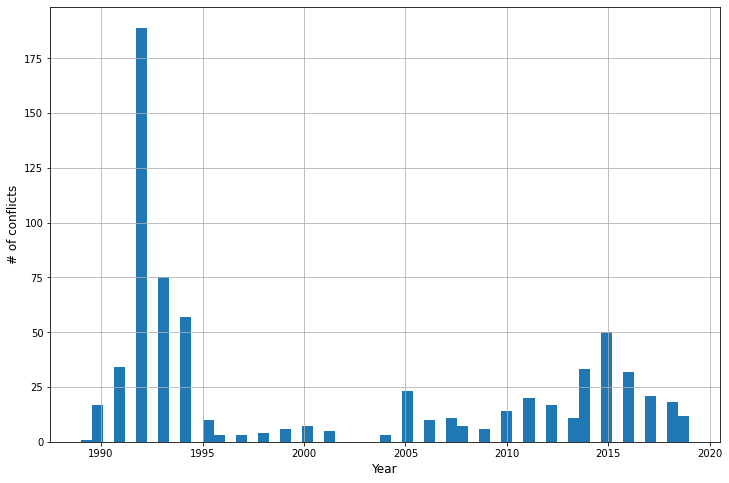

In [ ]:
artsakh_df['year'].hist(bins = 55, figsize = (12, 8))
plt.xlabel('Year', fontsize = 12)
plt.ylabel('# of conflicts', fontsize = 12)
plt.show()

In [ ]:
artsakh_df.columns

Index(['id', 'relid', 'year', 'active_year', 'code_status', 'type_of_violence',
       'conflict_dset_id', 'conflict_new_id', 'conflict_name', 'dyad_dset_id',
       'dyad_new_id', 'dyad_name', 'side_a_dset_id', 'side_a_new_id', 'side_a',
       'side_b_dset_id', 'side_b_new_id', 'side_b', 'number_of_sources',
       'source_article', 'source_office', 'source_date', 'source_headline',
       'source_original', 'where_prec', 'where_coordinates',
       'where_description', 'adm_1', 'adm_2', 'latitude', 'longitude',
       'geom_wkt', 'priogrid_gid', 'country', 'country_id', 'region',
       'event_clarity', 'date_prec', 'date_start', 'date_end', 'deaths_a',
       'deaths_b', 'deaths_civilians', 'deaths_unknown', 'best', 'high', 'low',
       'gwnoa', 'gwnob'],
      dtype='object')

Let's see if there are any missing values in `latitude` and `longitude` features.

In [ ]:
artsakh_df[['latitude', 'longitude']].isna().any()

latitude     False
longitude    False
dtype: bool

We see that there are no missing values, finally let's check visually if there are any abnormal observations (also known as outliers).

In [ ]:
# let's extract the unique values 
lat, lng = artsakh_df.latitude, artsakh_df.longitude
lons, lats = lng.unique(), lat.unique()

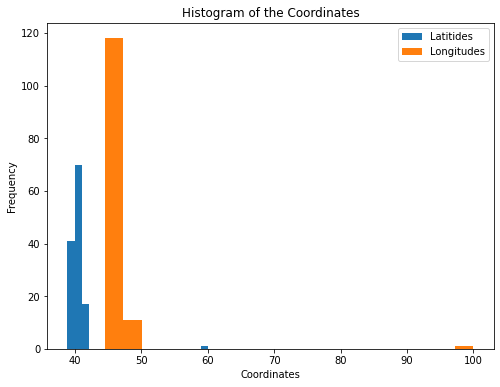

In [ ]:
# plot the histograms
plt.hist(lats, bins=20, label='Latitides')
plt.hist(lons, bins=20, label='Longitudes')
plt.legend()
plt.ylabel('Frequency')
plt.xlabel('Coordinates')
plt.title('Histogram of the Coordinates')
plt.show()

From the above histogram, we can see that there are some observations which are highly deviated from the rest. Let's also visualize the corresponding **boxplots**, which help us understand the overall range of the data.

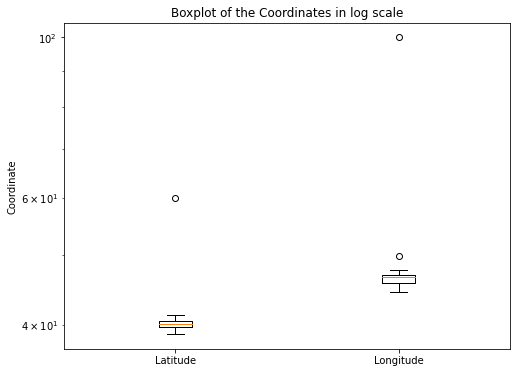

In [ ]:
# ploting the boxplots
plt.boxplot([lats, lons], labels=['Latitude', 'Longitude']);
plt.ylabel('Coordinate')
plt.title('Boxplot of the Coordinates in log scale')
plt.yscale('log');

From the boxplot it is clear that there is one outlier in each feature. We will exclude that point from our map.

In [ ]:
# there is an outlier which we don't want to display
lats = lats[lats < 50]
lons = lons[lons < 60]

In [ ]:
# creating a bounding box for the map
scale, alpha = 2, 0.5
lllat = lats.min() - 2
lllon = lons.min() - 2
urlat = lats.max() + 2
urlon = lons.max() + 2

print(lllat, lllon, urlat, urlon, 'is our bounding box')

36.866667 42.488333000000004 43.31156 51.882220000000004 is our bounding box


In [ ]:
from mpl_toolkits.basemap import Basemap 

ModuleNotFoundError: ignored

In [ ]:
# in case the basemap doesn't work

!apt-get install libgeos-3.5.0
!apt-get install libgeos-dev
!pip install https://github.com/matplotlib/basemap/archive/master.zip
!pip install pyproj==1.9.6

Reading package lists... Done
Building dependency tree       
Reading state information... Done
E: Unable to locate package libgeos-3.5.0
E: Couldn't find any package by glob 'libgeos-3.5.0'
E: Couldn't find any package by regex 'libgeos-3.5.0'
Reading package lists... Done
Building dependency tree       
Reading state information... Done
Suggested packages:
  libgdal-doc
The following NEW packages will be installed:
  libgeos-dev
0 upgraded, 1 newly installed, 0 to remove and 11 not upgraded.
Need to get 73.1 kB of archives.
After this operation, 486 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu bionic/universe amd64 libgeos-dev amd64 3.6.2-1build2 [73.1 kB]
Fetched 73.1 kB in 1s (56.8 kB/s)
Selecting previously unselected package libgeos-dev.
(Reading database ... 144676 files and directories currently installed.)
Preparing to unpack .../libgeos-dev_3.6.2-1build2_amd64.deb ...
Unpacking libgeos-dev (3.6.2-1build2) ...
Setting up libgeos-dev (3.6.2-1

     |████████████████████████████████| 2.8MB 2.8MB/s 
  Created wheel for pyproj: filename=pyproj-1.9.6-cp36-cp36m-linux_x86_64.whl size=3702120 sha256=8c6db0c2a35b280c187bd637181d921641df348f6dcdfc0c91ef133c16f84495
  Stored in directory: /root/.cache/pip/wheels/02/cd/b1/a2d6430f74c7a778a43d62f78bec109ca69c732dc9b929142a
Successfully built pyproj
  Found existing installation: pyproj 2.6.1.post1
    Uninstalling pyproj-2.6.1.post1:
      Successfully uninstalled pyproj-2.6.1.post1


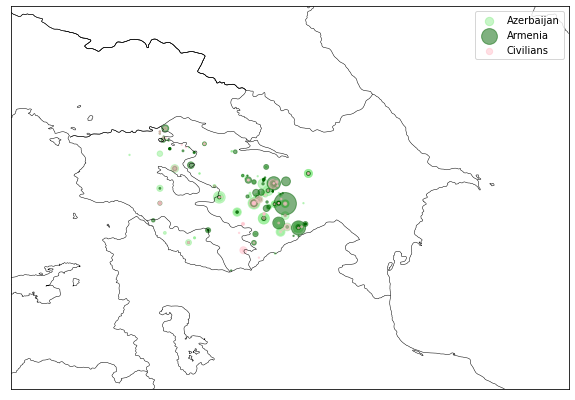

In [ ]:
from mpl_toolkits.basemap import Basemap 
# more on Basemap
# https://matplotlib.org/basemap/api/basemap_api.html

plt.figure(figsize=(10, 15))
mp = Basemap(llcrnrlat=lllat,
             llcrnrlon=lllon,
             urcrnrlat=urlat,
             urcrnrlon=urlon,
             resolution='f'
            )

mp.drawcountries()
mp.drawcoastlines(linewidth=0.5)

mp.scatter(lng, lat, s=artsakh_df['deaths_a']*scale,
           alpha=alpha, color='lightgreen', latlon=True, 
           label='Azerbaijan')
mp.scatter(lng, lat, s=artsakh_df['deaths_b']*scale,
           alpha=alpha, color='darkgreen', latlon=True, 
           label='Armenia')
mp.scatter(lng, lat, s=artsakh_df['deaths_civilians']*scale,
           alpha=alpha, color='pink', latlon=True, 
           label='Civilians')
plt.legend()
plt.show()

## Geopandas

In [ ]:
!pip install geopandas

     |████████████████████████████████| 972kB 2.8MB/s 
     |████████████████████████████████| 14.8MB 297kB/s 
  Using cached https://files.pythonhosted.org/packages/e5/c3/071e080230ac4b6c64f1a2e2f9161c9737a2bc7b683d2c90b024825000c0/pyproj-2.6.1.post1-cp36-cp36m-manylinux2010_x86_64.whl
  Found existing installation: pyproj 1.9.6
    Uninstalling pyproj-1.9.6:
      Successfully uninstalled pyproj-1.9.6


Let's creat a GeoDataFrame from a DataFrame with coordinates.

In [ ]:
import geopandas as gpd

In [ ]:
artsakh_df = artsakh_df.query('latitude < 50 & longitude < 60')

gdf = gpd.GeoDataFrame(
    artsakh_df, geometry=gpd.points_from_xy(artsakh_df.longitude,
                                    artsakh_df.latitude))


In [ ]:
gdf.head()

,id,relid,year,active_year,code_status,type_of_violence,conflict_dset_id,conflict_new_id,conflict_name,dyad_dset_id,dyad_new_id,dyad_name,side_a_dset_id,side_a_new_id,side_a,side_b_dset_id,side_b_new_id,side_b,number_of_sources,source_article,source_office,source_date,source_headline,source_original,where_prec,where_coordinates,where_description,adm_1,adm_2,latitude,longitude,geom_wkt,priogrid_gid,country,country_id,region,event_clarity,date_prec,date_start,date_end,deaths_a,deaths_b,deaths_civilians,deaths_unknown,best,high,low,gwnoa,gwnob,geometry
39805,153561,AZE-1992-1-361-196,1992,1,Clear,1,388,388,Azerbaijan: Artsakh (Nagorno-Karabakh),833,833,Government of Azerbaijan - Republic of Artsakh,64,64,Government of Azerbaijan,338,338,Republic of Artsakh,1,"""BBC Monitoring Service: Former USSR,1992-02-2...",BBC Monitoring Service: Former USSR,1992-02-21,State of emergency declared in parts on NKAO.,ITAR-TAss,4,Gorisskiy rayon,Gorisskiy rayon,Gorisskiy rayon,NaN,39.50000,46.33333,POINT (46.333330 39.500000),186933,Armenia,371,Europe,1,1,1992-02-21 00:00:00.000,1992-02-21 00:00:00.000,0,0,1,0,1,1,1,373,NaN,POINT (46.33333 39.50000)
39806,154147,AZE-1992-1-361-106,1992,1,Clear,1,388,388,Azerbaijan: Artsakh (Nagorno-Karabakh),833,833,Government of Azerbaijan - Republic of Artsakh,64,64,Government of Azerbaijan,338,338,Republic of Artsakh,1,"""Reuters News,1992-06-15,AZERI OFFENSIVE GATHE...",Reuters News,1992-06-15,AZERI OFFENSIVE GATHERS PACE IN NAGORNO-KARABAKH.,Snark news agency,6,Armenia,NaN,NaN,NaN,40.00000,45.00000,POINT (45.000000 40.000000),187651,Armenia,371,Europe,1,1,1992-06-15 00:00:00.000,1992-06-15 00:00:00.000,0,0,0,3,3,3,3,373,NaN,POINT (45.00000 40.00000)
39807,154235,AZE-1992-1-361-127,1992,1,Clear,1,388,388,Azerbaijan: Artsakh (Nagorno-Karabakh),833,833,Government of Azerbaijan - Republic of Artsakh,64,64,Government of Azerbaijan,338,338,Republic of Artsakh,1,"""BBC Monitoring Service: Former USSR,1992-08-0...",BBC Monitoring Service: Former USSR,1992-08-03,Fierce fighting for Karabakh town of Mardakert.,the National Self-Determination Association,6,Armenia,the village of Movses,NaN,NaN,40.00000,45.00000,POINT (45.000000 40.000000),187651,Armenia,371,Europe,1,1,1992-08-01 00:00:00.000,1992-08-01 00:00:00.000,0,0,0,0,0,40,0,373,NaN,POINT (45.00000 40.00000)
39808,154304,AZE-1992-1-361-136,1992,1,Clear,1,388,388,Azerbaijan: Artsakh (Nagorno-Karabakh),833,833,Government of Azerbaijan - Republic of Artsakh,64,64,Government of Azerbaijan,338,338,Republic of Artsakh,1,"""Reuters News,1992-08-12,AZERIS AND ARMENIANS ...",Reuters News,1992-08-12,AZERIS AND ARMENIANS BATTLE OVER NAGORNO-KARAB...,Nega news agency,6,Armenia,border region,NaN,NaN,40.00000,45.00000,POINT (45.000000 40.000000),187651,Armenia,371,Europe,1,1,1992-08-11 00:00:00.000,1992-08-11 00:00:00.000,0,0,0,3,3,3,3,373,NaN,POINT (45.00000 40.00000)
39809,154645,AZE-1992-1-361-176,1992,1,Clear,1,388,388,Azerbaijan: Artsakh (Nagorno-Karabakh),833,833,Government of Azerbaijan - Republic of Artsakh,64,64,Government of Azerbaijan,338,338,Republic of Artsakh,1,"""Reuters News,1992-12-12,Armenia says 32 kille...",Reuters News,1992-12-12,Armenia says 32 killed in Azeri attacks.,the Pro Armenia news agency,1,Kapan town,the town of Kafan,Kapan rayon,NaN,39.20755,46.40576,POINT (46.405760 39.207550),186213,Armenia,371,Europe,1,1,1992-12-12 00:00:00.000,1992-12-12 00:00:00.000,0,0,25,0,25,25,25,373,NaN,POINT (46.40576 39.20755)


Now, let's plot the coordinates over a map.

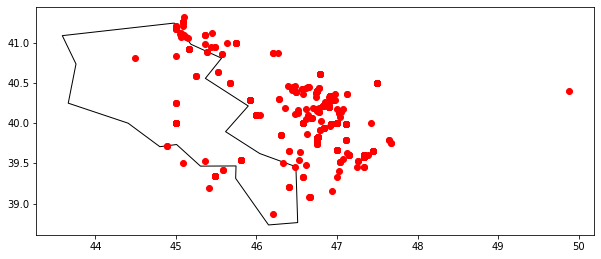

In [ ]:
plt.rcParams['figure.figsize'] = 10, 8

world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


# We restrict to Armenia.
ax = world.query('name == "Armenia"').plot(
    color='white', edgecolor='black')

# We can now plot our ``GeoDataFrame``.


gdf.plot(ax=ax, color='red')

plt.show()

It is also possible to set a normal background map to this plot.

## Folium

In [ ]:
import folium

In [ ]:
artsakh_df.head()

,id,relid,year,active_year,code_status,type_of_violence,conflict_dset_id,conflict_new_id,conflict_name,dyad_dset_id,dyad_new_id,dyad_name,side_a_dset_id,side_a_new_id,side_a,side_b_dset_id,side_b_new_id,side_b,number_of_sources,source_article,source_office,source_date,source_headline,source_original,where_prec,where_coordinates,where_description,adm_1,adm_2,latitude,longitude,geom_wkt,priogrid_gid,country,country_id,region,event_clarity,date_prec,date_start,date_end,deaths_a,deaths_b,deaths_civilians,deaths_unknown,best,high,low,gwnoa,gwnob,geometry
39805,153561,AZE-1992-1-361-196,1992,1,Clear,1,388,388,Azerbaijan: Artsakh (Nagorno-Karabakh),833,833,Government of Azerbaijan - Republic of Artsakh,64,64,Government of Azerbaijan,338,338,Republic of Artsakh,1,"""BBC Monitoring Service: Former USSR,1992-02-2...",BBC Monitoring Service: Former USSR,1992-02-21,State of emergency declared in parts on NKAO.,ITAR-TAss,4,Gorisskiy rayon,Gorisskiy rayon,Gorisskiy rayon,NaN,39.50000,46.33333,POINT (46.333330 39.500000),186933,Armenia,371,Europe,1,1,1992-02-21 00:00:00.000,1992-02-21 00:00:00.000,0,0,1,0,1,1,1,373,NaN,POINT (46.33333 39.50000)
39806,154147,AZE-1992-1-361-106,1992,1,Clear,1,388,388,Azerbaijan: Artsakh (Nagorno-Karabakh),833,833,Government of Azerbaijan - Republic of Artsakh,64,64,Government of Azerbaijan,338,338,Republic of Artsakh,1,"""Reuters News,1992-06-15,AZERI OFFENSIVE GATHE...",Reuters News,1992-06-15,AZERI OFFENSIVE GATHERS PACE IN NAGORNO-KARABAKH.,Snark news agency,6,Armenia,NaN,NaN,NaN,40.00000,45.00000,POINT (45.000000 40.000000),187651,Armenia,371,Europe,1,1,1992-06-15 00:00:00.000,1992-06-15 00:00:00.000,0,0,0,3,3,3,3,373,NaN,POINT (45.00000 40.00000)
39807,154235,AZE-1992-1-361-127,1992,1,Clear,1,388,388,Azerbaijan: Artsakh (Nagorno-Karabakh),833,833,Government of Azerbaijan - Republic of Artsakh,64,64,Government of Azerbaijan,338,338,Republic of Artsakh,1,"""BBC Monitoring Service: Former USSR,1992-08-0...",BBC Monitoring Service: Former USSR,1992-08-03,Fierce fighting for Karabakh town of Mardakert.,the National Self-Determination Association,6,Armenia,the village of Movses,NaN,NaN,40.00000,45.00000,POINT (45.000000 40.000000),187651,Armenia,371,Europe,1,1,1992-08-01 00:00:00.000,1992-08-01 00:00:00.000,0,0,0,0,0,40,0,373,NaN,POINT (45.00000 40.00000)
39808,154304,AZE-1992-1-361-136,1992,1,Clear,1,388,388,Azerbaijan: Artsakh (Nagorno-Karabakh),833,833,Government of Azerbaijan - Republic of Artsakh,64,64,Government of Azerbaijan,338,338,Republic of Artsakh,1,"""Reuters News,1992-08-12,AZERIS AND ARMENIANS ...",Reuters News,1992-08-12,AZERIS AND ARMENIANS BATTLE OVER NAGORNO-KARAB...,Nega news agency,6,Armenia,border region,NaN,NaN,40.00000,45.00000,POINT (45.000000 40.000000),187651,Armenia,371,Europe,1,1,1992-08-11 00:00:00.000,1992-08-11 00:00:00.000,0,0,0,3,3,3,3,373,NaN,POINT (45.00000 40.00000)
39809,154645,AZE-1992-1-361-176,1992,1,Clear,1,388,388,Azerbaijan: Artsakh (Nagorno-Karabakh),833,833,Government of Azerbaijan - Republic of Artsakh,64,64,Government of Azerbaijan,338,338,Republic of Artsakh,1,"""Reuters News,1992-12-12,Armenia says 32 kille...",Reuters News,1992-12-12,Armenia says 32 killed in Azeri attacks.,the Pro Armenia news agency,1,Kapan town,the town of Kafan,Kapan rayon,NaN,39.20755,46.40576,POINT (46.405760 39.207550),186213,Armenia,371,Europe,1,1,1992-12-12 00:00:00.000,1992-12-12 00:00:00.000,0,0,25,0,25,25,25,373,NaN,POINT (46.40576 39.20755)


In [ ]:
deaths_cols = list(map(lambda x: 'deaths' in x,
                       artsakh_df.columns))
artsakh_df['total_deaths'] = artsakh_df.loc[:, deaths_cols].sum(axis=1)

In [ ]:
lats = artsakh_df.latitude.unique()
lons = artsakh_df.longitude.unique()

map_osm = folium.Map(location=[lats.mean(), lons.mean()],
                     zoom_start=7)

artsakh_df.apply(lambda row: folium.CircleMarker(
    location=[row["latitude"],
              row["longitude"]], 
              popup=str(row['total_deaths']),
              tooltip=row['side_a'],
              fill=True, 
              radius=row['total_deaths']/10).add_to(map_osm), axis=1)

map_osm.add_child(folium.LatLngPopup())
map_osm

# Visualize with Seaborn
Matplotlib has proven to be an incredibly useful and popular visualization tool, but in cases when the task to be performed is becoming complicated, **Seaborn** helps.

Seaborn provides an API on top of Matplotlib that offers many choices for plot style and color defaults, defines simple high-level functions for common statistical plot types, and integrates with the functionality provided by Pandas DataFrames.

In [ ]:
import seaborn as sns
sns.set() # set the style in Seaborn

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [ ]:
rng = np.random.RandomState(0)
x = np.linspace(0, 10, 500)
y = np.cumsum(rng.randn(500, 6), 0)

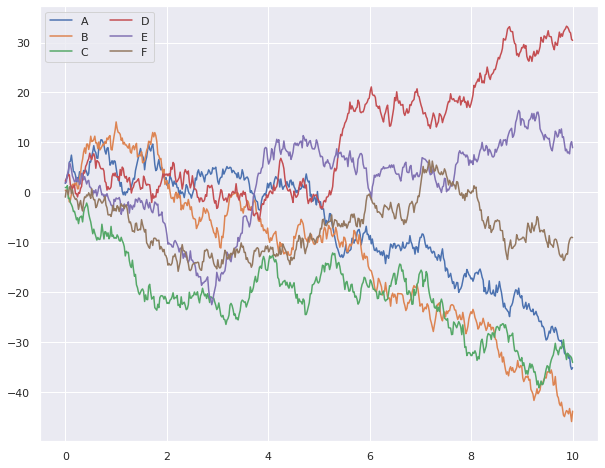

In [ ]:
plt.plot(x, y)
plt.legend('ABCDEF', ncol=2, loc='upper left');

## Seaborn Plots
The main idea of Seaborn is that it provides high-level commands to create a variety of plot types useful for statistical data exploration, and even some statistical model fitting.

### Histograms, KDE, and densities
Often in statistical data visualization, all you want is to plot histograms and joint distributions of variables. We have seen that this is relatively straightforward in Matplotlib:

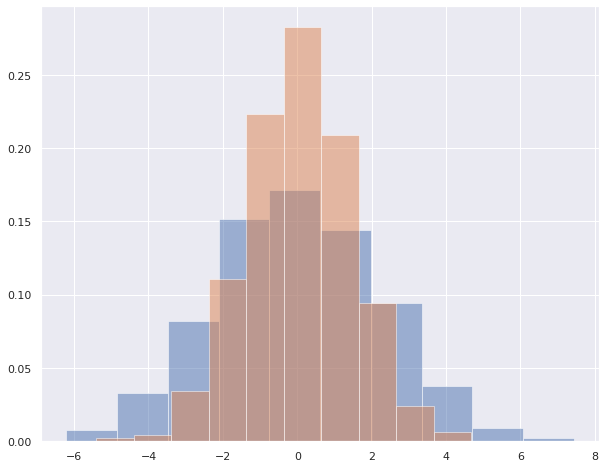

In [ ]:
data = np.random.multivariate_normal([0, 0],
                                     [[5, 2],
                                      [2, 2]], size=2000)
data = pd.DataFrame(data, columns=['x', 'y'])

for col in 'xy':
    plt.hist(data[col], density=True, alpha=0.5)

Rather than a histogram, we can get a smooth estimate of the distribution using a kernel density estimation, which Seaborn does with **sns.kdeplot**:

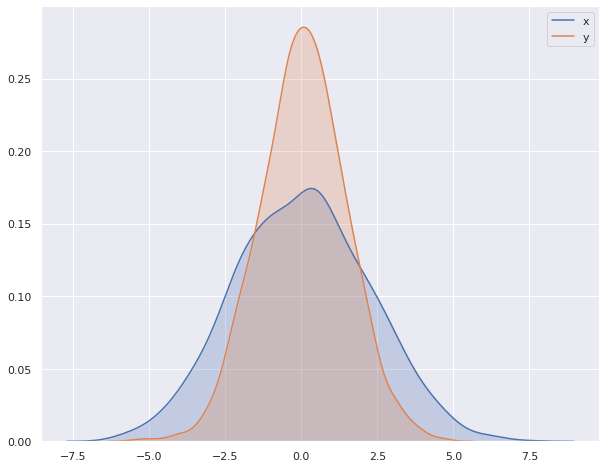

In [ ]:
for col in 'xy':
    sns.kdeplot(data[col], shade=True)

Histograms and KDE can be combined using **distplot**:

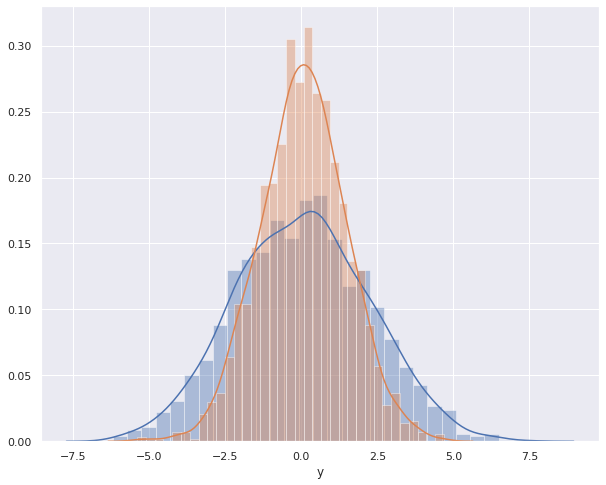

In [ ]:
sns.distplot(data['x'])
sns.distplot(data['y']);

We can alse get a two-dimensional visualization of the data:

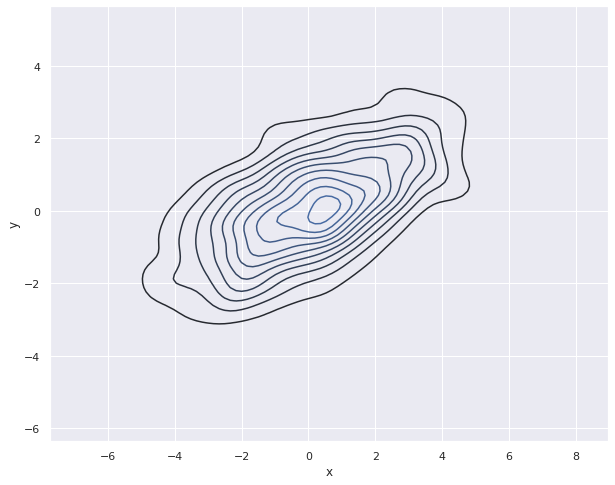

In [ ]:
sns.kdeplot(data['x'], data['y']);

We can see the joint distribution and the marginal distributions together using **sns.jointplot**. For this plot, we'll set the style to a white background:

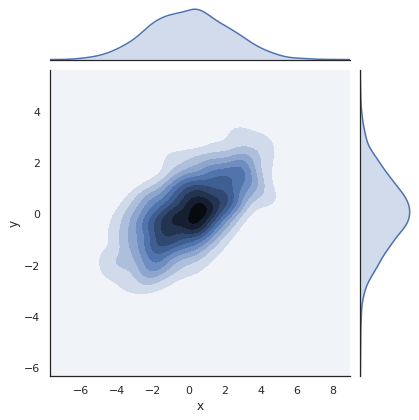

In [ ]:
with sns.axes_style('white'):
    sns.jointplot("x", "y", data, kind='kde');

There are other parameters that can be passed to **jointplot** — for example, we can use a hexagonally based histogram instead:

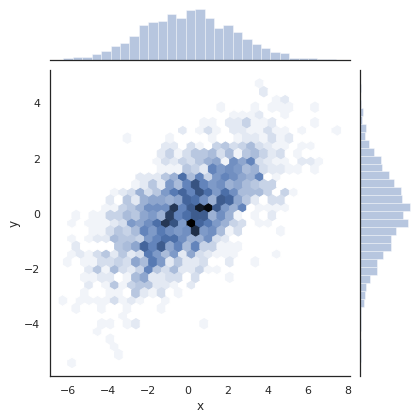

In [ ]:
with sns.axes_style('white'):
    sns.jointplot("x", "y", data, kind='hex')

## Pair plots
Pair plots are a very useful for exploring correlations between multidimensional data, when you'd like to plot all pairs of values against each other.

We'll demo this with the well-known Iris dataset, which lists measurements of petals and sepals of three iris species:

In [ ]:
iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Visualizing the multidimensional relationships among the samples is as easy as calling **sns.pairplot**:

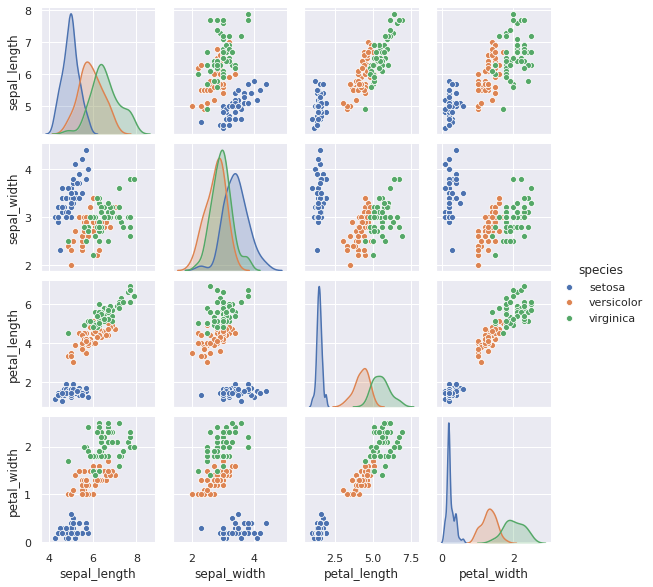

In [ ]:
sns.pairplot(iris, hue='species', height=2);

### Faceted histograms

Sometimes the best way to view data is via histograms of subsets. Seaborn's FacetGrid makes this extremely simple. We'll take a look at some data that shows the amount that restaurant staff receive in tips based on various indicator data:

In [ ]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


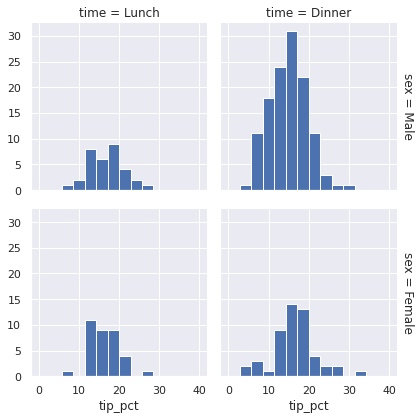

In [ ]:
tips['tip_pct'] = 100 * tips['tip'] / tips['total_bill']

grid = sns.FacetGrid(tips, row="sex", col="time", margin_titles=True)

grid.map(plt.hist, "tip_pct", bins=np.linspace(0, 40, 15));

## Heatmap

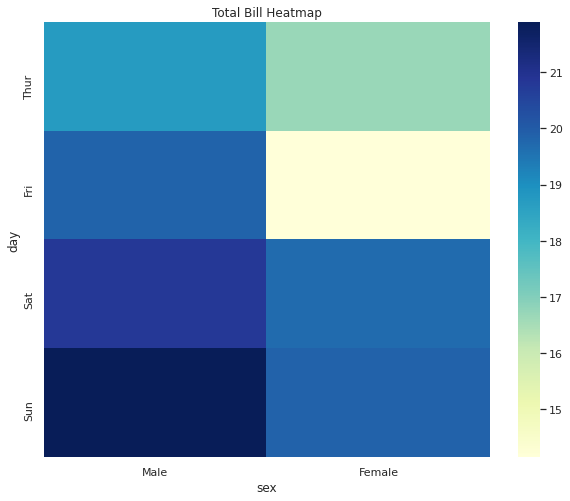

In [ ]:
tips_grouped = tips.pivot_table(index='day',
                                columns='sex',
                                values='total_bill')

plt.title('Total Bill Heatmap')
sns.heatmap(tips_grouped, cmap="YlGnBu");

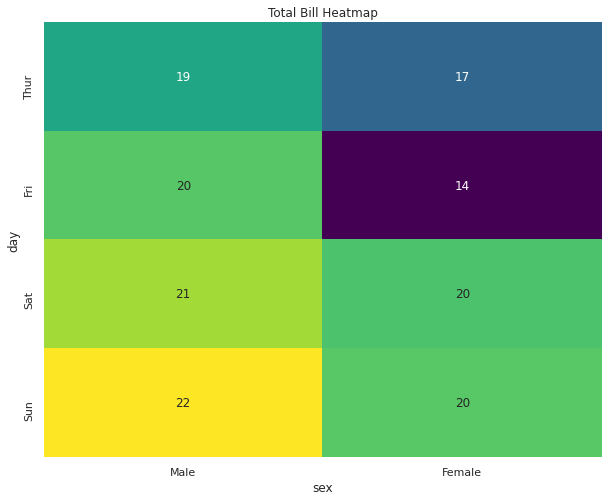

In [ ]:
# in case we want to display the actual values
# and hide the color bar
plt.title('Total Bill Heatmap')
sns.heatmap(tips_grouped, cmap="viridis",
            cbar=False, annot=True);

### Category plots
Category plots can be useful for this kind of visualization as well. This allows you to view the distribution of a parameter (with a `boxplot`) within bins defined by any other parameter:

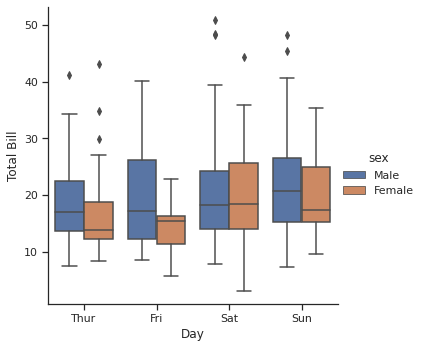

In [ ]:
with sns.axes_style(style='ticks'):
    g = sns.catplot("day", "total_bill", "sex", data=tips, kind="box")
    g.set_axis_labels("Day", "Total Bill");

### Joint distributions
Similar to the pairplot we saw earlier, we can use sns.jointplot to show the joint distribution between different datasets, along with the associated marginal distributions:

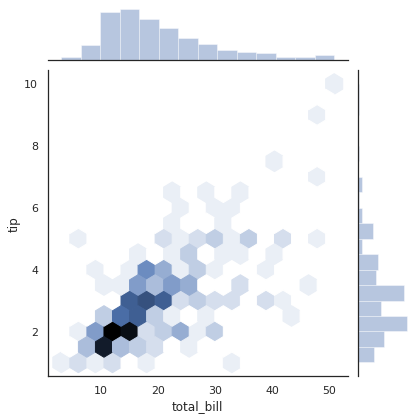

In [ ]:
with sns.axes_style('white'):
    sns.jointplot("total_bill", "tip", data=tips, kind='hex')

The joint plot can even do some automatic kernel density estimation and regression:

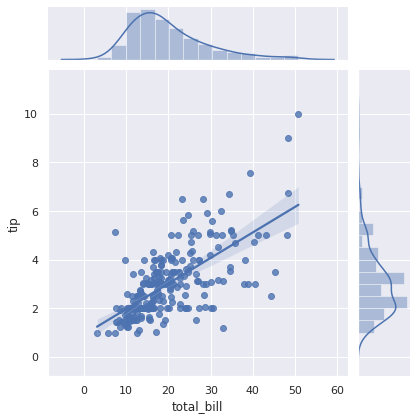

In [ ]:
sns.jointplot("total_bill", "tip", data=tips, kind='reg');

### Bar plots
Time series can be plotted using **sns.catplot**. In the following example, we'll use the Planets data:

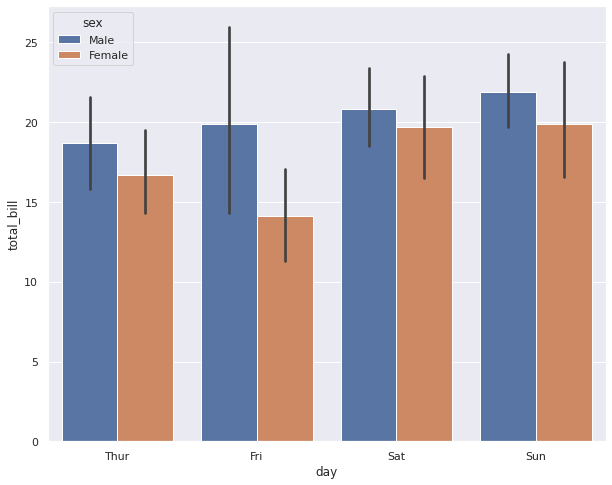

In [ ]:
ax = sns.barplot(x="day", y="total_bill", hue="sex", data=tips);

In [ ]:
planets = sns.load_dataset('planets')
planets.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


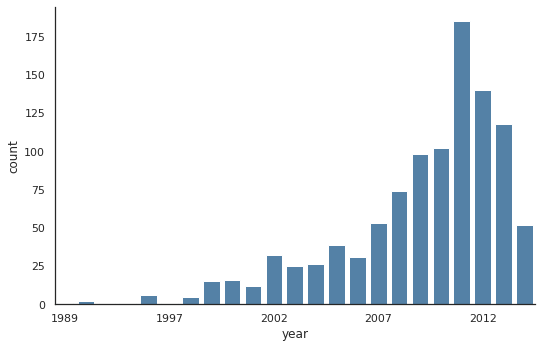

In [ ]:
with sns.axes_style('white'):
    g = sns.catplot("year", data=planets, aspect=1.5,
                       kind="count", color='steelblue')
    g.set_xticklabels(step=5)

We can learn more by looking at the method of discovery of each of these planets:

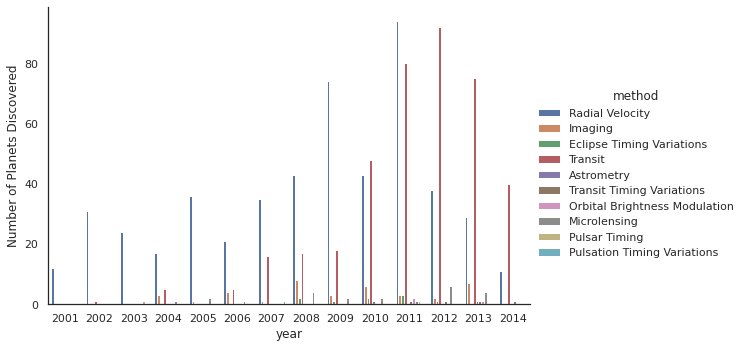

In [ ]:
# change the size of this plot
with sns.axes_style('white'):
    g = sns.catplot("year", data=planets, aspect=1.5, kind='count',
                       hue='method', order=range(2001, 2015))
    g.set_ylabels('Number of Planets Discovered')
# plt.yscale('log')

# Visualize with Plotly

`Plotly` makes interactive, publication-quality graphs and animations. [Here](https://plot.ly/python/) you can find some example graphs with their code. Let's have a look at a few examples here.

Plotly charts are described declaratively with objects in `plotly.graph_objects` and `dict`. Every aspect of a plotly chart (colors, grids, data etc) has a corresponding `key-value` attribute in these objects. [This page](https://plot.ly/python/reference/) contains an extensive list of these attributes.

Plotly's graph description places attributes into two categories: 

* traces (objects that describe a single series of data in a graph like Scatter or Heatmap)
* layout attributes that apply to the rest of the chart, like the title, xaxis, or annotations).

Here is a simple example of a plotly chart.

In [2]:
import plotly.graph_objects as go

fig = go.Figure([
    go.Scatter(         
        x=[1, 2, 3],    
        y=[3, 1, 6],    
       
        marker=dict(      
            color="rgb(16, 32, 77)"     
        )
    ),
    go.Bar(              
        x=[1, 2, 3],     
        y=[3, 1, 6],     
        name="bar chart example"   
    )
])

fig.update_layout(        
    title="Simple example",
    width=800,
    height=550,     
    xaxis=dict(                 
        title="time"            
    )
)

fig.show()

Hover over the above plot to see what we mean by saying an interactive plot.

In [3]:
N = 100
random_x = np.linspace(0, 1, N)
random_y0 = np.random.randn(N) + 5
random_y1 = np.random.randn(N)
random_y2 = np.random.randn(N) - 5

fig = go.Figure()

# Add traces
fig.add_trace(go.Scatter(x=random_x, y=random_y0,
                    mode='markers',
                    name='markers'))
fig.add_trace(go.Scatter(x=random_x, y=random_y1,
                    mode='lines+markers',
                    name='lines+markers'))
fig.add_trace(go.Scatter(x=random_x, y=random_y2,
                    mode='lines',
                    name='lines'))

fig.update_layout(title='Another example', width=800, height=400)

fig.show()

Now let's make an animation with `Plotly`.

In [7]:
f = lambda u: u ** 2 
x = np.linspace(-10, 10, 100)
y = f(x)

x_min = min(x)
x_max = max(x)


# Create figure
fig = go.Figure(
    data=[
          go.Scatter(x=x, y=y,
                     mode="lines",
                     name="",
                     line=dict(width=2, color="blue")
                     ),
          go.Scatter(x=x, y=y,
                     name="curve",
                     mode="lines",
                     line=dict(width=2, color="blue"))
          ],
    frames=[go.Frame(
        data=[go.Scatter(x=x, y=f(k) + 2 * k * (x - k),
                    mode='lines',
                    name='tangent line',
                    line={"color": 'red'})
        ]) for k in x]
)

fig.update_layout(
    width=600, height=600,
    title="Tangent Line Over a Curve",
    xaxis=dict(range=[x_min, x_max]),
    yaxis=dict(range=[-10, f(x_max)]),
    transition_duration=0,
    updatemenus=[
                dict(type="buttons",
                      buttons=[
                              dict(label="Play",
                                    method="animate",
                                    args=[None,
                                          dict(
                                              frame={"duration": 100}                                               
                                               )
                                          ]
                                   ),
                              dict(label='Pause',
                                   method='animate',
                                   args=[[None],
                                         dict(frame={
                                             "duration": 0,
                                             "redraw": False
                                             },
                                              mode='immediate',
                                              transition={'duration': 0})]
                                   )
                              ]
                     )
                ]
                )


fig.show()

Press `Play` in the above graph to see the animation. 

# Visualize images


There are common benchmark datasets used by the machine learning community, which can be downloaded from the ML packages such as `sklearn`. Some of those datasets are related to images. Let's plot some of the images from well known image datasets.

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


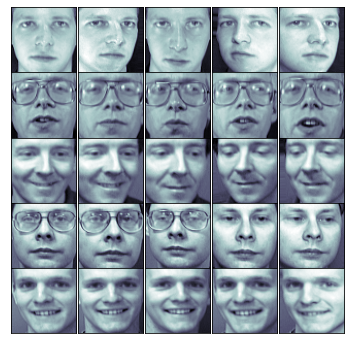

In [8]:
fig, ax = plt.subplots(5, 5, figsize=(6, 6))
fig.subplots_adjust(hspace=0, wspace=0)
# Get some face data from scikit-learn
from sklearn.datasets import fetch_olivetti_faces
faces = fetch_olivetti_faces().images
for i in range(5):
  for j in range(5):
    ax[i, j].xaxis.set_major_locator(plt.NullLocator())
    ax[i, j].yaxis.set_major_locator(plt.NullLocator())
    ax[i, j].imshow(faces[10 * i + j], cmap="bone")

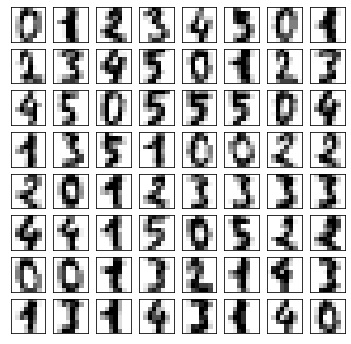

In [9]:
from sklearn.datasets import load_digits
digits = load_digits(n_class=6)
fig, ax = plt.subplots(8, 8, figsize=(6, 6))
for i, axi in enumerate(ax.flat):
  axi.imshow(digits.images[i], cmap='binary')
  axi.set(xticks=[], yticks=[])

Now let's see how we can display images loaded by us. We will use [`OpenCV`](https://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_setup/py_intro/py_intro.html#intro) open-source Computer Vision library. Upload the images from `Lab_files` folder to Colab storage.

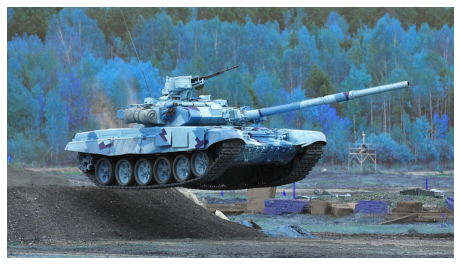

In [10]:
import cv2
tank_img = cv2.imread('T-90 (1).jpg')
plt.figure(figsize=(8, 8))
plt.imshow(tank_img)
plt.axis('off');

In [12]:
tank_img.shape

(478, 850, 3)

Notice that something is strange with the colors. This is because by default `OpenCV` uses BGR (Blue, Green, Reg) color coding. We will display the image in RGB format. 

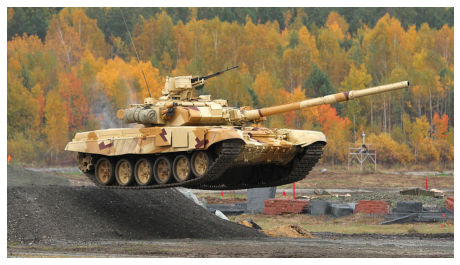

In [13]:
plt.figure(figsize=(8, 8))
tank_img_rgb = cv2.cvtColor(tank_img, cv2.COLOR_BGR2RGB)
plt.imshow(tank_img_rgb)
plt.axis('off');

In [ ]:
tank_img.shape

In [14]:
# blue
print('Blue:', np.allclose(tank_img[:, :, 0], tank_img_rgb[:, :, 2]))
# green
print('Green:', np.allclose(tank_img[:, :, 1], tank_img_rgb[:, :, 1]))
# red
print('Red:', np.allclose(tank_img[:, :, 2], tank_img_rgb[:, :, 0]))

# or equivalently
print('BGR to RGB:', np.allclose(tank_img[:, :, [2, 1, 0]], tank_img_rgb))

Blue: True
Green: True
Red: True
BGR to RGB: True


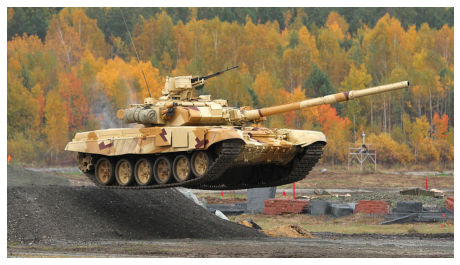

In [17]:
plt.figure(figsize=(8, 8))
# plt.imshow(tank_img[:, :, ::-1]) # BGR to RGB
plt.imshow(tank_img[:, :, [2, 1, 0]]) # BGR to RGB
plt.axis('off');

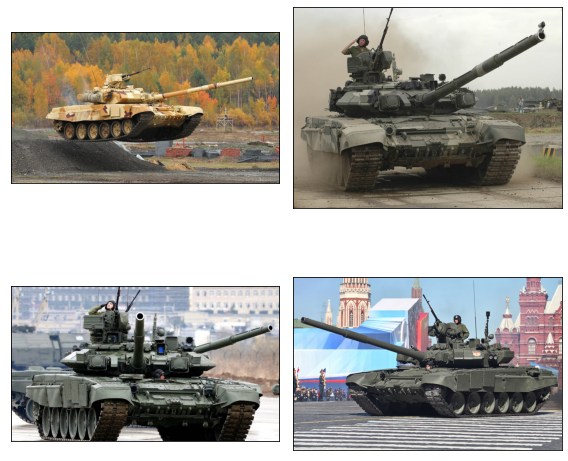

In [18]:
# to display several images 
fig, ax = plt.subplots(2, 2, figsize=(8, 8))
for i, axi in enumerate(ax.flat):
  img = cv2.imread('T-90 ({}).jpg'.format(i+1))
  axi.imshow(img[:, :, [2, 1, 0]])
  axi.set(xticks=[], yticks=[])
fig.tight_layout();

We can also display the image with 1 channel.

In [20]:
tank_img[:, :, 2]

array([[110,  96,  87, ..., 127, 101,  93],
       [112,  98,  90, ..., 116, 105,  98],
       [124, 103,  87, ..., 107, 103,  99],
       ...,
       [172, 126, 172, ..., 114, 124, 117],
       [158, 109, 136, ..., 117,  98,  96],
       [130, 178, 169, ..., 116, 115, 101]], dtype=uint8)

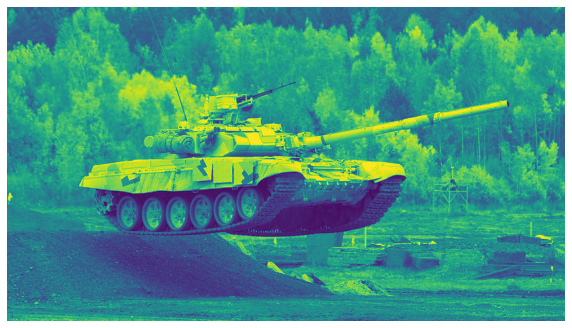

In [19]:
plt.rcParams['figure.figsize'] = 10, 8
plt.imshow(tank_img[:, :, 2])
plt.axis('off');

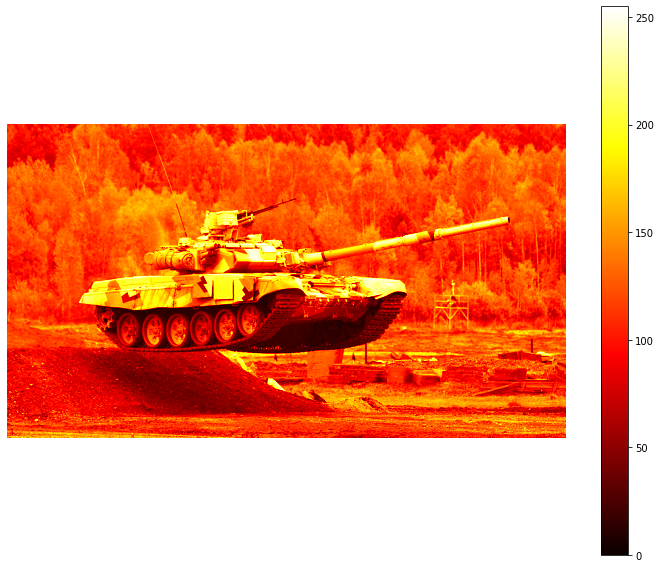

In [21]:
plt.imshow(tank_img[:, :, 1], cmap='hot')
plt.axis('off')
plt.colorbar()
plt.tight_layout();

# Visualize Gradient Descent

In [47]:
def gradient_descent(grad_f, x0, tol=0.01, alpha=0.05):
  if len(x0) == 1:
    plot_points = lambda x, y: plt.plot(x, g(x), marker='.', color=y)
  else:
    plot_points = lambda x, y: plt.plot(x[0], x[1], marker='.', color=y)
    
  x = x0
  nr_iterations = 1
  while np.linalg.norm(grad_f(x0)) > tol:
    nr_iterations += 1
    plot_points(x0, 'red')
    x = x0 - alpha * grad_f(x0)
    x0 = x
  plot_points(x0, 'k')
  print(f'The algorithm converged in {nr_iterations} steps!')  
  return x

## Function with one variable

$$g(x) = \begin{cases} -cos(\pi x), \text{if } x \leq 1 \\
(x-2)^2, \text{if } x > 1
\end{cases}
$$

In [23]:
def g(x):
  return -np.cos(x * np.pi) * (x <= 1) + (x-2) ** 2 * (x > 1)
  
def grad_g(x):
  return (x <= 1) * np.pi * np.sin(x * np.pi) + (x > 1) * 2 * (x-2)

The algorithm converged in 62 steps!


array([2.00485193])

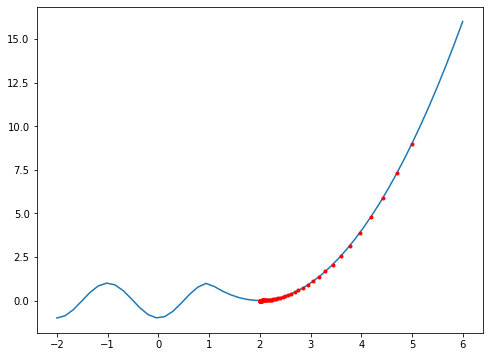

In [31]:
x = np.linspace(-2, 6, 50)
y = g(x)
plt.figure(figsize=(8, 6))
plt.plot(x, y);
gradient_descent(grad_g, np.array([5]), alpha=0.05)

## Function with two variables

In [32]:
def f(x):
  # x = (x_1, x_2), so that f:R^2 -> R
  return np.sin(x[0]) ** 10 + np.cos(10 + x[1] * x[0] ) * np.cos(x[0]) 

def grad_f(x):
  u = 10 + x[1] * x[0]
  fx1 = 10 * np.sin(x[0])**9-np.sin(u)*x[1]*np.cos(x[0])-np.sin(x[0])*np.cos(u) 
  fx2 = -np.cos(x[0]) * x[0] * np.sin(u)
  return np.array([fx1, fx2])

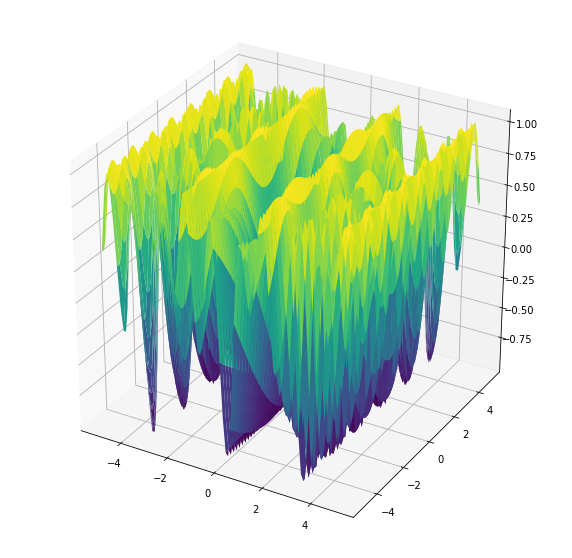

In [33]:
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)

X, Y = np.meshgrid(x, y)
Z = f(np.array([X, Y]))

plt.figure(figsize=(10, 10))
ax = plt.axes(projection='3d')
ax.plot_surface(X,Y,Z, cmap='viridis', edgecolor='none');

The algorithm converged in 512 steps!


array([-0.1733493 ,  2.98068086])

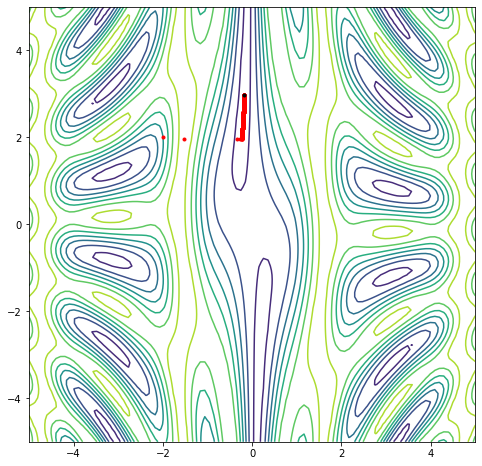

In [48]:
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)

X, Y = np.meshgrid(x, y)
Z = f(np.array([X, Y]))

plt.figure(figsize=(8,8))
plt.contour(X, Y, Z);
gradient_descent(grad_f, np.array([-2, 2]), alpha=0.13)